In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [4]:
df = pd.read_csv("../Dataset/cleaned_accidents.csv")

In [7]:
df.head()

,Severity,Start_Time,Temperature(F),Humidity(%),Visibility(mi),Weather_Condition,City,State,Start_Lat,Start_Lng,Hour,Month,Day
0,3,2016-02-08 05:46:00,36.9,91.0,10.0,Light Rain,Dayton,OH,39.865147,-84.058723,5,2,8
1,2,2016-02-08 06:07:59,37.9,100.0,10.0,Light Rain,Reynoldsburg,OH,39.928059,-82.831184,6,2,8
2,2,2016-02-08 06:49:27,36.0,100.0,10.0,Overcast,Williamsburg,OH,39.063148,-84.032608,6,2,8
3,3,2016-02-08 07:23:34,35.1,96.0,9.0,Mostly Cloudy,Dayton,OH,39.747753,-84.205582,7,2,8
4,2,2016-02-08 07:39:07,36.0,89.0,6.0,Mostly Cloudy,Dayton,OH,39.627781,-84.188354,7,2,8


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7240402 entries, 0 to 7240401
Data columns (total 13 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Severity           int64  
 1   Start_Time         str    
 2   Temperature(F)     float64
 3   Humidity(%)        float64
 4   Visibility(mi)     float64
 5   Weather_Condition  str    
 6   City               str    
 7   State              str    
 8   Start_Lat          float64
 9   Start_Lng          float64
 10  Hour               int64  
 11  Month              int64  
 12  Day                int64  
dtypes: float64(5), int64(4), str(4)
memory usage: 718.1 MB


In [9]:
df.shape

(7240402, 13)

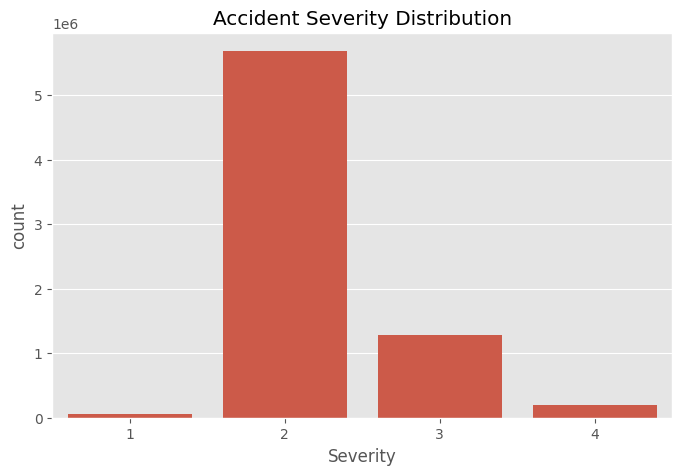

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Severity',
    data=df
)

plt.title('Accident Severity Distribution')

plt.show()

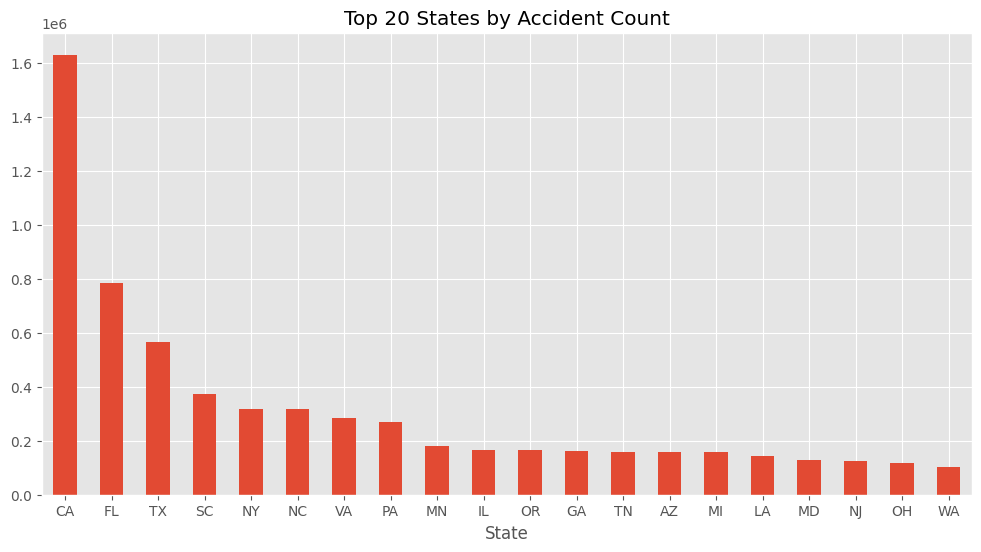

In [12]:
top_states = df['State'].value_counts().head(20)

plt.figure(figsize=(12,6))

top_states.plot(kind='bar')

plt.title("Top 20 States by Accident Count")

plt.xticks(rotation=0)

plt.savefig(
    "../Images/state_analysis.png"
)

plt.show()

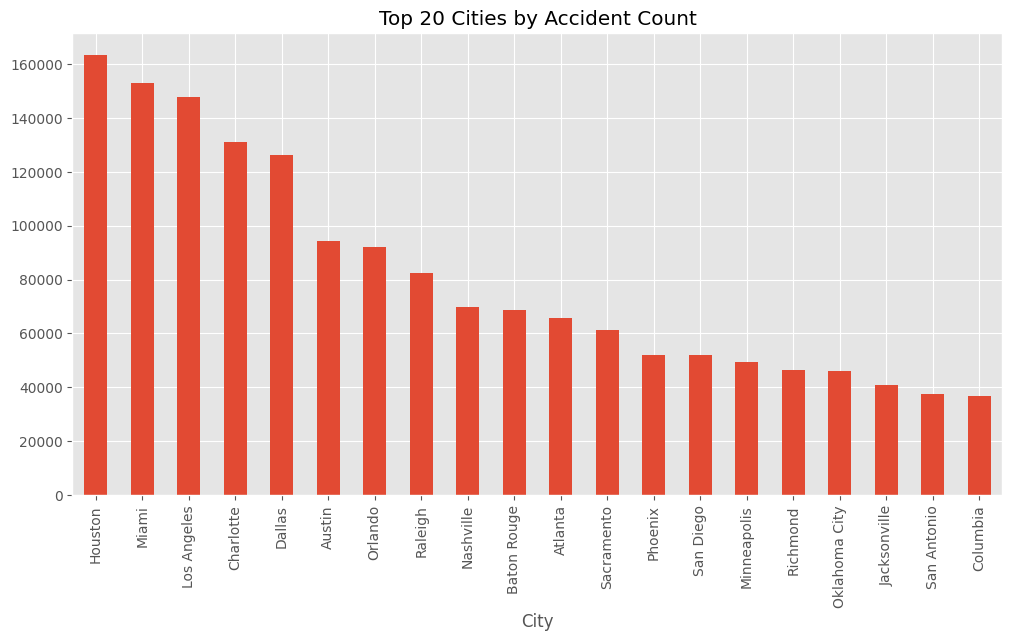

In [13]:
top_cities = df['City'].value_counts().head(20)
plt.figure(figsize=(12,6))
top_cities.plot(kind='bar')
plt.title("Top 20 Cities by Accident Count")
plt.xticks(rotation=90)
plt.savefig(
    "../Images/city_analysis.png"
)
plt.show()

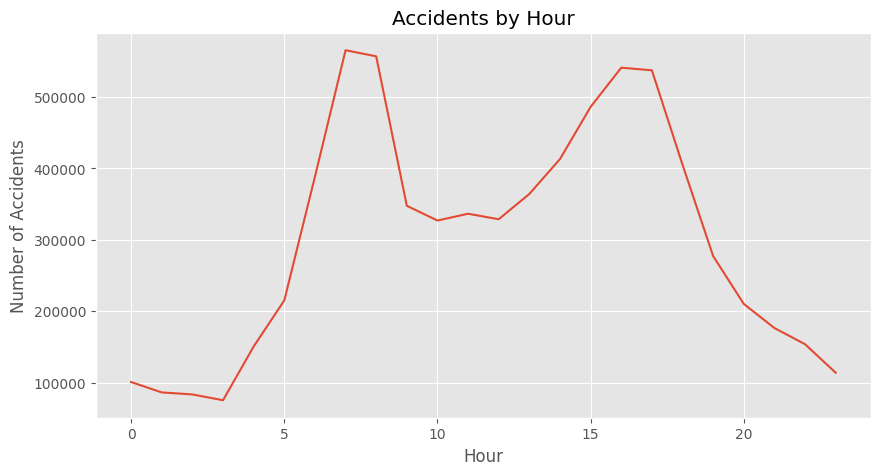

In [15]:
hourly = df['Hour'].value_counts()
plt.figure(figsize=(10,5))
hourly.sort_index().plot()
plt.title("Accidents by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.savefig(
    "../Images/hourly_analysis.png"
)
plt.show()


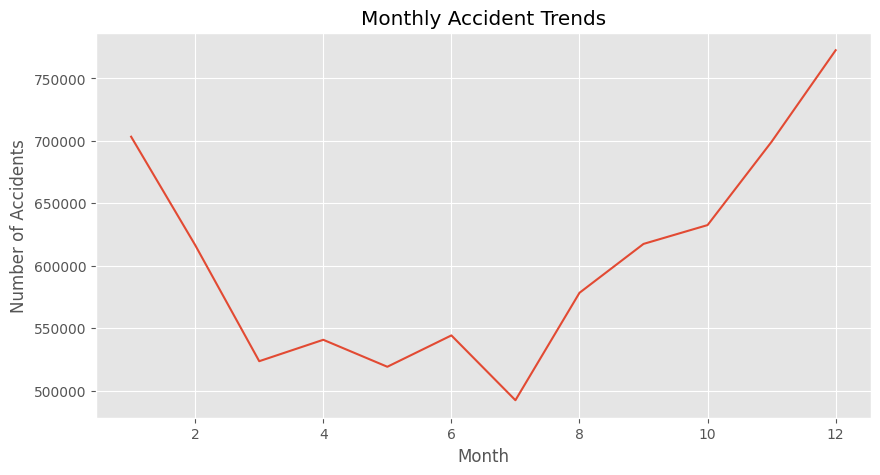

In [16]:
monthly = df['Month'].value_counts().sort_index()
plt.figure(figsize=(10,5))
monthly.plot()
plt.title("Monthly Accident Trends")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.savefig(
    "../Images/monthly_analysis.png"
)
plt.show()

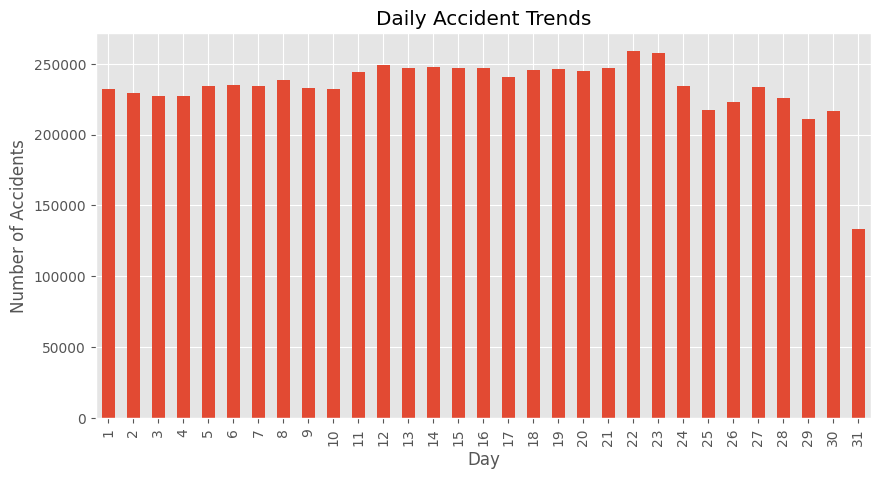

In [17]:
days = df['Day'].value_counts().sort_index()
plt.figure(figsize=(10,5))
days.plot(kind='bar')
plt.title("Daily Accident Trends")
plt.xlabel("Day")
plt.ylabel("Number of Accidents")
plt.savefig(
    "../Images/daily_analysis.png"
)
plt.show()

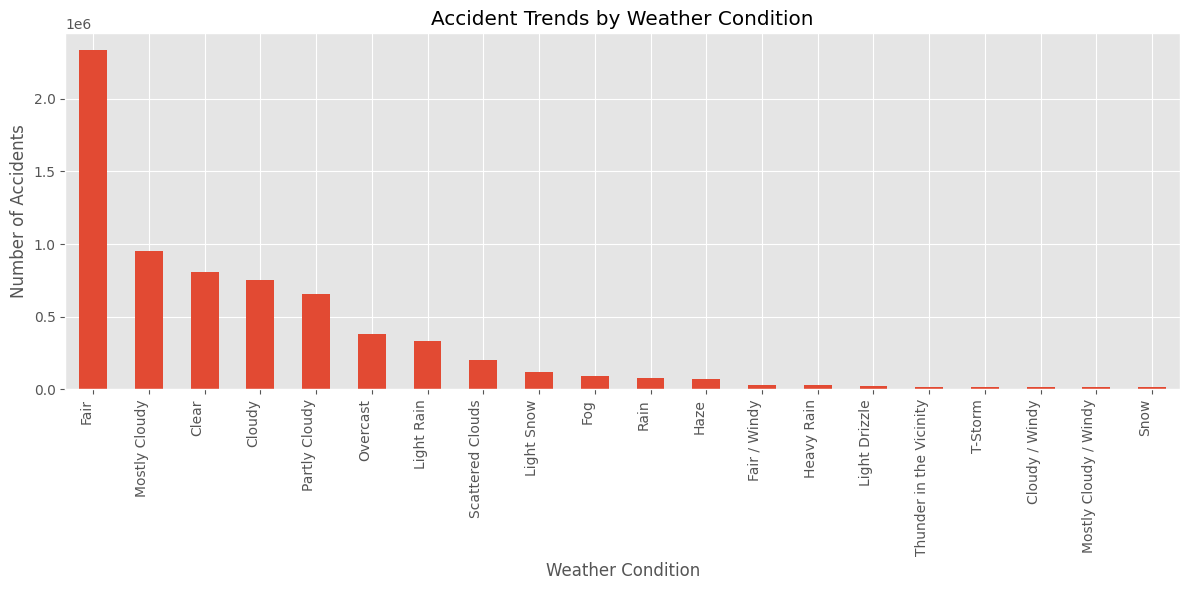

In [20]:
weather = df['Weather_Condition'].value_counts().head(20)
plt.figure(figsize=(12,6))
weather.plot(kind='bar')
plt.title("Accident Trends by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.savefig("../Images/weather_analysis.png")
plt.show()

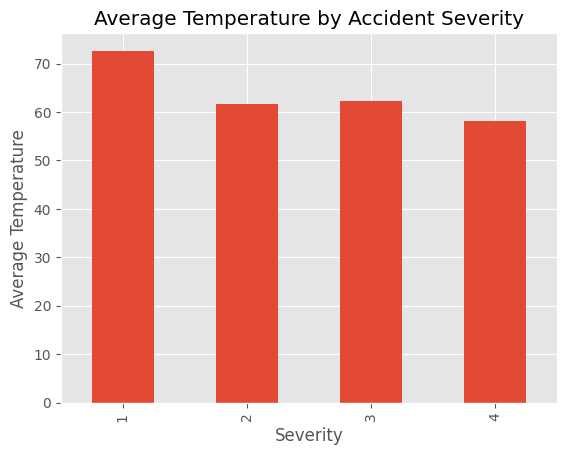

In [22]:
temp = df.groupby('Severity')['Temperature(F)'].mean()
temp.plot(kind='bar')
plt.title("Average Temperature by Accident Severity")
plt.xlabel("Severity")
plt.ylabel("Average Temperature")
plt.savefig("../Images/temp_vs_severity.png")
plt.show()

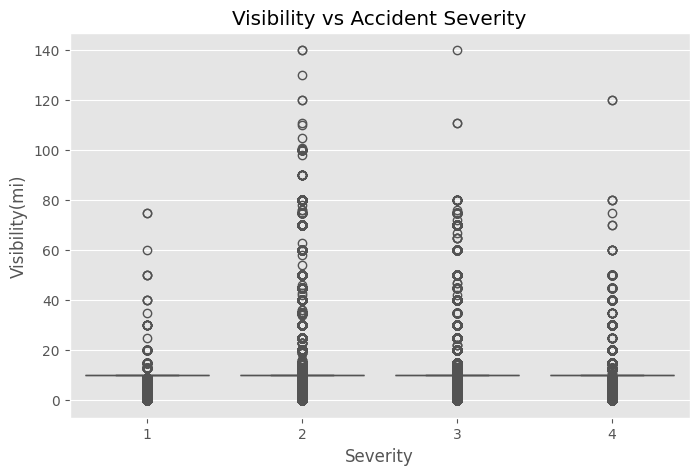

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Severity', y='Visibility(mi)', data=df)
plt.title("Visibility vs Accident Severity")
plt.xlabel("Severity")
plt.savefig("../Images/visibility_vs_severity.png")
plt.show()

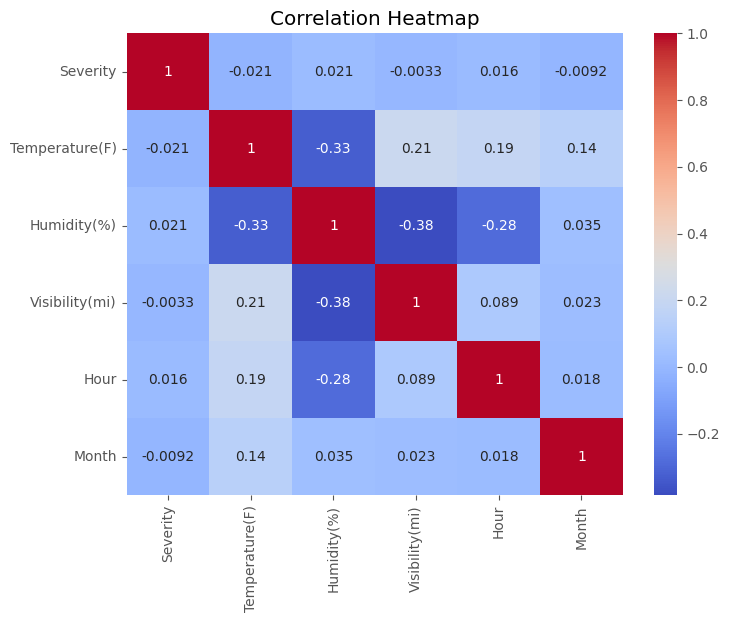

In [24]:
numeric_columns = [
    'Severity',
    'Temperature(F)',
    'Humidity(%)',
    'Visibility(mi)',
    'Hour',
    'Month'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Correlation Heatmap"
)

plt.savefig(
    "../Images/correlation_heatmap.png"
)

plt.show()